# Processamento Digital de Sinais
![Texto Alternativo](imagens/UFCG_logo_png.png)
### Aluno: 
- Elmer Pimentel Farias

### Professor: 
- Dr. Edmar Candeia Gurjão, Professor do Departamento de Engenharia Elétrica da Universidade Federal de Campina Grande (UFCG)

## Problemática

No arquivo "sinal_1.wav" foi gravado um sinal composto de soma de cossenos amostrados a uma frequência de 16 kHz. Deseja-se conhecer quantas componentes (cossenos) formam esse sinal;

Também foi solicitado um sistema que separe as componentes do sinal gravado.

Sua tarefa é atender as solicitações acima entregando um conjunto de filtros que separe as compontentes do sinal em gráficos separados (você só dispõe de filtros FIR);

In [ ]:
import numpy as np #Importa biblioteca matematica para FFT e manipulação de arrays
import matplotlib.pyplot as plt # Importa biblioteca para plotagem de gráficos
from scipy.io import wavfile # Importa a função para ler arquivos WAV com a taxa de amostragem
from scipy.signal import firwin, lfilter # Importa as funções para projetar e aplicar o filtro FIR

#### 1- Realizar a FFT do sinal para descobrir as componestes dos cossenos em suas respectivas frequencias 

O sinal tem uma frequência de Amostragem de {fs} Hz


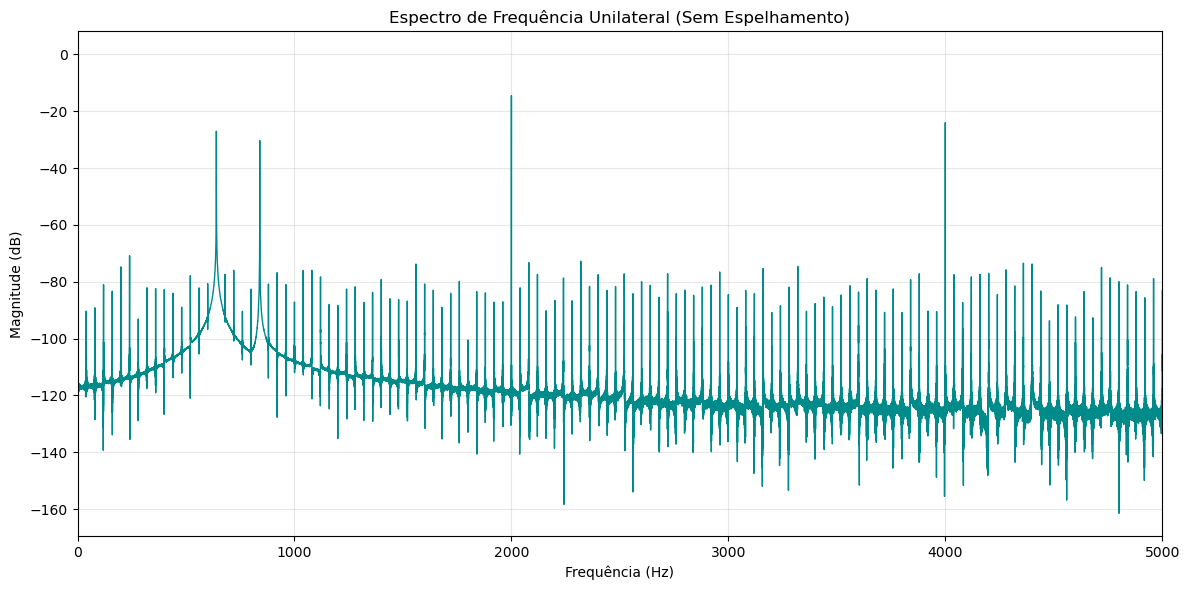

In [10]:
# 1. Carregar o arquivo
fs, data = wavfile.read('./audios/sinal_1.wav')# Normalizar o sinal se necessário

print("O sinal tem uma frequência de Amostragem de {fs} Hz")

if len(data.shape) > 1:
    data = data[:, 0]

# Normalizamos a amplitude para facilitar a visualização (entre -1 e 1)
data = data / np.max(np.abs(data))

# 2. Cálculo da FFT
n = len(data)
fft_values = np.fft.fft(data)
freqs = np.fft.fftfreq(n, d=1/fs)

# 3. Pegar apenas frequências positivas
indices_positivos = np.where(freqs >= 0)
f_plot = freqs[indices_positivos]
magnitude_linear = np.abs(fft_values[indices_positivos])

# 4. Conversão para Decibéis (dB)
# Normalizamos pela magnitude máxima para que o pico principal seja 0 dB
magnitude_db = 20 * np.log10(magnitude_linear / np.max(magnitude_linear))

# 5. Visualização com ZOOM e Escala em dB
plt.figure(figsize=(12, 6))
plt.plot(f_plot, magnitude_db, color='darkcyan', linewidth=1)

plt.title('Espectro de Frequência Unilateral (Sem Espelhamento)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim(0,5000)  # Limita até 8000 Hz (Nyquist)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.signal import find_peaks # Importa a função para encontrar as componentes principais

In [9]:
# 1. Encontrar os índices dos picos
# 'height=-50' significa que ele só vai considerar picos acima de -50dB
# 'distance=20' evita pegar múltiplos pontos de um mesmo pico largo
indices, properties = find_peaks(magnitude_db, height=-50, distance=20)

# 2. Mapear esses índices para as frequências e magnitudes reais
freqs_exatas = f_plot[indices]
magnitudes_picos = magnitude_db[indices]

# 3. Exibir os resultados com precisão
print("-" * 30)
print(f"Foram encontradas {len(freqs_exatas)} componentes:")
for i, (f, mag) in enumerate(zip(freqs_exatas, magnitudes_picos)):
    print(f"Componente {i+1}: {f:.2f} Hz  (Magnitude: {mag:.2f} dB)")
print("-" * 30)


------------------------------
Foram encontradas 4 componentes:
Componente 1: 639.98 Hz  (Magnitude: -27.05 dB)
Componente 2: 839.99 Hz  (Magnitude: -30.36 dB)
Componente 3: 2000.00 Hz  (Magnitude: -14.54 dB)
Componente 4: 4000.00 Hz  (Magnitude: -24.07 dB)
------------------------------


#### 2- Filtrar/Separar as componentes de frequência usando filtros FIR

O Tipo de Filtro: Passa-Faixa (Band-Pass)Para isolar cada componente, usaremos o Filtro FIR Passa-Faixa.

- Seletividade: Um filtro passa-faixa permite que apenas uma pequena "janela" de frequências passe (ex: de $600\text{ Hz}$ a $700\text{ Hz}$), bloqueando todo o resto. Como suas componentes estão próximas (especialmente a de $640\text{ Hz}$ e $840\text{ Hz}$), precisamos de um corte preciso.

- Fase Linear: Sendo um filtro FIR (Finite Impulse Response), ele garante que todas as frequências sofram o mesmo atraso temporal. Isso é crucial para que, se você somar os sinais separados depois, eles se alinhem perfeitamente sem distorção de fase.

- Estabilidade: Diferente dos filtros IIR, os filtros FIR nunca oscilam sozinhos ou se tornam instáveis, o que é ideal para processar sinais de áudio fixos.

- Usaremos o TIPO II de filtros FIR: Tipo 2 é extremamente eficiente para filtros Passa-Faixa e Passa-Baixa.Como ele já possui um zero natural na frequência de Nyquist ($8000\text{ Hz}$), ele acaba ajudando o filtro a atenuar frequências muito altas "de graça", o que pode resultar em uma rejeição de ruído ligeiramente melhor em altas frequências se comparado a um Tipo 1 com o mesmo número de taps.

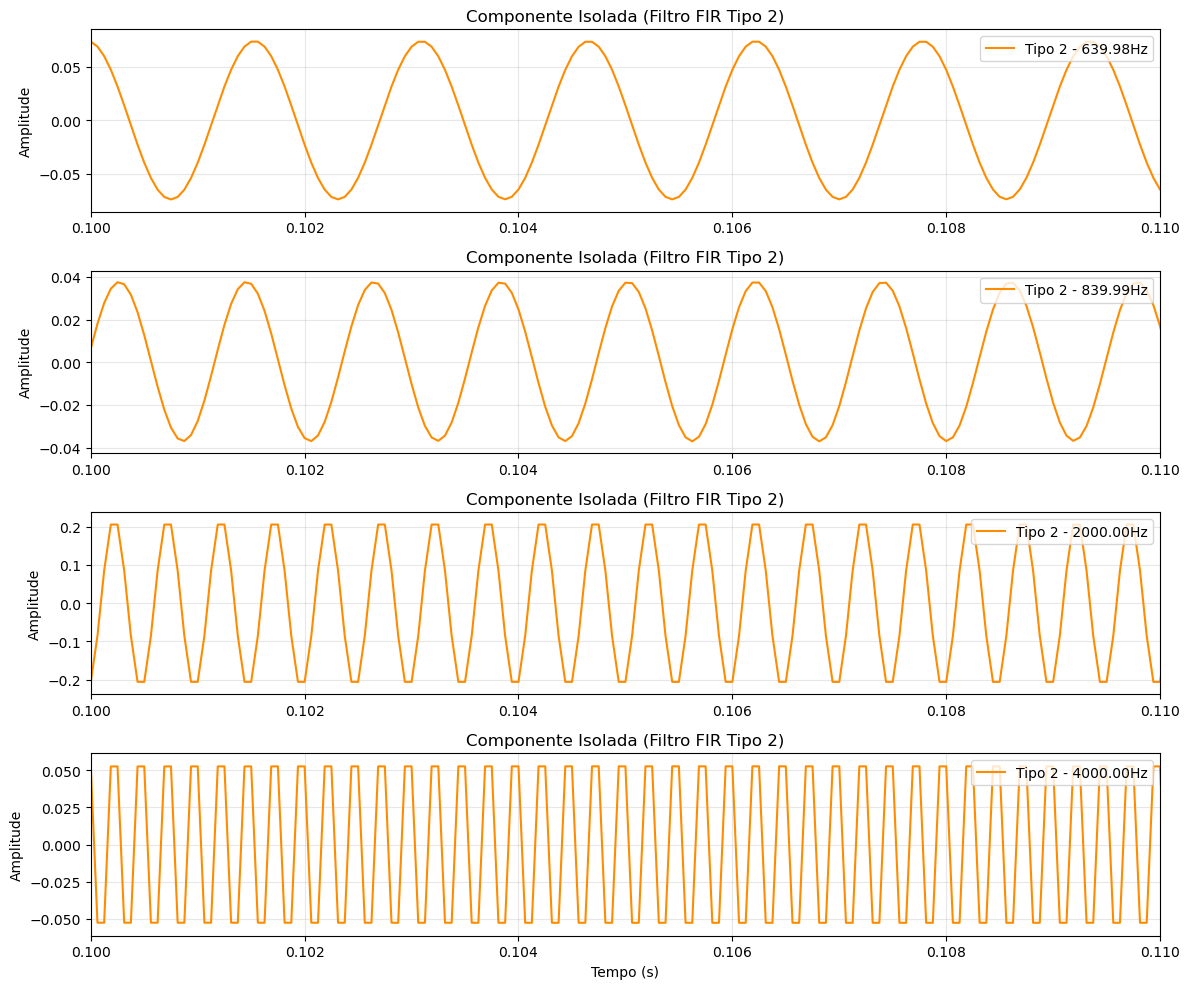

In [ ]:
# 1. Configurações
fs = 16000 #frequencia de amostragrem
freqs_exatas = [639.98, 839.99, 2000.00, 4000.00]

# Carregar o áudio
fs_in, data = wavfile.read('./audios/sinal_1.wav')
if len(data.shape) > 1: data = data[:, 0]
data = data / np.max(np.abs(data))

# 2. Parâmetros do Filtro Tipo 2
numtaps = 1000  # NÚMERO PAR = FILTRO TIPO 2
tempo = np.arange(len(data)) / fs

plt.figure(figsize=(12, 10))

for i, f_alvo in enumerate(freqs_exatas):
    # Banda de passagem (ajustada para ser estreita)
    margem = 40
    banda = [f_alvo - margem, f_alvo + margem]
    
    # firwin com numtaps PAR gera o Tipo 2 para Passa-Faixa
    taps = firwin(numtaps, banda, fs=fs, pass_zero=False)
    
    # Aplicação do filtro
    sinal_filtrado = lfilter(taps, 1.0, data)
    
    # Cálculo do atraso para alinhar o gráfico (opcional)
    atraso = (numtaps - 1) / 2
    
    # Plotagem com zoom no tempo (0.1s a 0.11s)
    plt.subplot(4, 1, i+1)
    plt.plot(tempo, sinal_filtrado, color='darkorange', label=f'Tipo 2 - {f_alvo:.2f}Hz')
    plt.title(f"Componente Isolada (Filtro FIR Tipo 2)")
    plt.xlim(0.1, 0.11)
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.xlabel("Tempo (s)")
plt.tight_layout()
plt.show()


#### 3- Salvar em audio as componentes de frequência isoladas para cada frequência encontrada

In [16]:
# 1. Configurações e Carregamento
fs = 16000
freqs_exatas = [639.98, 839.99, 2000.00, 4000.00]

# Carrega o sinal original
# Certifique-se de que o caminho está correto para o seu ambiente
samplerate, data = wavfile.read('./audios/sinal_1.wav')
if len(data.shape) > 1: data = data[:, 0]

# Normalização inicial (importante para o áudio não clipar)
data = data.astype(np.float32)
data /= np.max(np.abs(data))

# 2. Processamento com Filtro FIR Tipo 2 e Exportação
numtaps = 1000 # Par para garantir Tipo 2 em Passa-Faixa

print("Iniciando a separação e exportação...")

for f_alvo in freqs_exatas:
    # Projeto do filtro
    margem = 40
    banda = [f_alvo - margem, f_alvo + margem]
    taps = firwin(numtaps, banda, fs=fs, pass_zero=False)
    
    # Aplicação do filtro
    sinal_isolado = lfilter(taps, 1.0, data)
    
    # Normalização individual da componente 
    # (garante que todas tenham um volume bom para ouvir)
    sinal_isolado /= np.max(np.abs(sinal_isolado))
    
    # Nome do arquivo baseado na frequência
    nome_arquivo = f'componente_{int(f_alvo)}Hz.wav'
    
    # Salvando o arquivo .wav
    # Usamos float32 para manter a fidelidade do processamento
    wavfile.write(nome_arquivo, fs, sinal_isolado.astype(np.float32))
    
    print(f"-> Arquivo '{nome_arquivo}' gerado com sucesso!")


Iniciando a separação e exportação...
-> Arquivo 'componente_639Hz.wav' gerado com sucesso!
-> Arquivo 'componente_839Hz.wav' gerado com sucesso!
-> Arquivo 'componente_2000Hz.wav' gerado com sucesso!
-> Arquivo 'componente_4000Hz.wav' gerado com sucesso!
